In [1]:
#%pip install subprocess
import uproot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import subprocess
from enum import IntEnum, auto
from pathlib import Path
import Settings
import FluctuationAnalysis
import Cascades

In [2]:
Setting = Settings.Setting
settings = Settings.settings
setting_definer = Settings.setting_definer
value_setting = Settings.value_setting

rainier_sample_folder = Settings.rainier_sample_folder
this_dir = Settings.this_dir
std_path = Settings.std_path

settings_data = {
        "Setting" : Setting,
        "settings" : settings,
        "setting_definer" : setting_definer,
        "value_setting" : value_setting,
        "rainier_sample_folder" : rainier_sample_folder,
        "this_dir" : this_dir,
        "std_path" : std_path
}

In [3]:
fluc = FluctuationAnalysis.FluctuationAnalysis(settings_data)
casc = Cascades.Cascades(settings_data)

In [ ]:
#run = fluc.run_simulation()
# energy, spin_array = fluc.get_level_arrays(fluc.get_level_data(run))
# fa = fluc.fluctuation_analysis(energy, spin_array[5])
# fluc.plot_fluctuation_analysis(energy, fa, std_path)

const int g_nReal = 1
const int g_nZ = 32
const int g_nAMass = 76
const int g_nConEBin = 600
(changed) const int g_nEvent = 3e5


In [11]:
with open(std_path / "run.txt", "w") as f:
    f.write(run)

In [4]:
with open(std_path / "run.txt", "r") as f:
    run = f.read()

In [ ]:
energy, bin_counter = casc.from_cascades_get_binned_events()

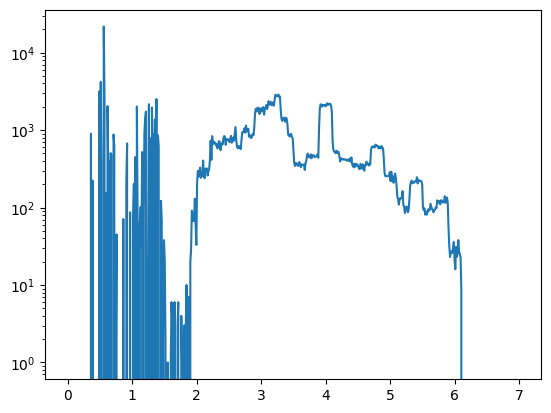

In [6]:
plt.plot(energy, bin_counter)
plt.yscale("log")
plt.savefig(std_path / "MyTestNumber3.png", dpi = 300)

In [7]:
fa = fluc.fluctuation_analysis(energy, bin_counter)
fluc.plot_fluctuation_analysis(energy, fa, file_name="Beta1")

In [9]:
def generate_event_count_slider_plots(ev_start, ev_step, ev_end, *, bin = settings[Setting.g_nConEBin]):
    event_count0 = settings[Setting.g_nEvent]
    global run
    run0 = run
    energy, bin_counter = ([],[])
    print(np.arange(ev_start, ev_end, ev_step))
    for k in np.arange(ev_start, ev_end, ev_step):
        print()
        settings[Setting.g_nEvent] = int(np.floor(k))
        print("start sim")
        run = run_simulation()
        print("end sim")
        energy, bin_counter = from_cascades_get_binned_events(bin)
        plt.figure()
        plt.plot(energy, bin_counter)
        plt.yscale("log")
        plt.savefig(std_path / "events" / str(int(np.floor(k))), dpi = 300)
    run = run0
    settings[Setting.g_nEvent] = event_count0
    return energy, bin_counter

[100000]

start sim
const int g_nReal = 1
const int g_nZ = 32
const int g_nAMass = 76
(changed) const int g_nConEBin = 600
(changed) const int g_nEvent = 100000
end sim


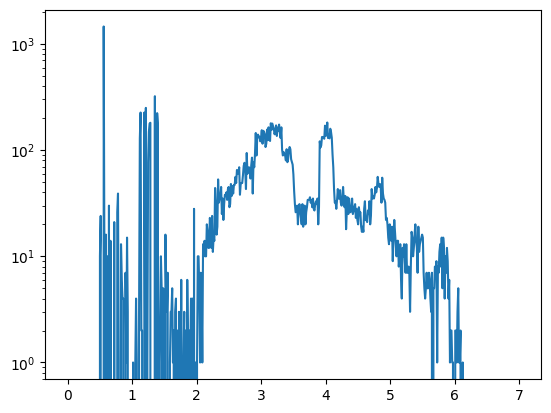

In [32]:
energy, bin_counter = generate_event_count_slider_plots(100000, 1, 100001)
